# Dr. Case Notebook
# P3: Text Exploration

REQ: Open notebooks with a standard header including a good title, your company/name/alias, a link to the repo, purpose, and date.

- Author: [Denise Case](https://github.com/denisecase/)
- Repository: [nlp-03-text-exploration](https://github.com/denisecase/nlp-03-text-exploration/)
- Date: 2026-03

Purpose

  Perform exploratory analysis of a small, controlled text corpus.
  Demonstrate how structure emerges from token distributions,
  category comparisons, and co-occurrence patterns.

Analytical Questions

- What tokens dominate each category?
- How do categories differ in vocabulary?
- What words appear in similar contexts?
- What structure is visible before using any models?

Notes

- This module focuses on exploratory analysis (EDA), not modeling.
- Results here prepare for later work with pipelines and embeddings.

Project Instructions

- See [docs/project-instructions.md](../docs/project-instructions.md)
- See [docs/glossary.md](../docs/glossary.md)

## Terminology

In preparation for large language models and related methods, our analysis does not begin with semantic interpretation.
Instead, we focus on **proximity** and observable **patterns** in the text.

We evaluate **co-occurrence (context windows)**, 
that is, _which words tend to appear near each other_.

The full collection of text is called a **corpus** (a set of documents).
For this analysis, each document is represented as a single line of text.

See the README.md for more

This is a Markdown cell.

## Section 0. Intro to Jupyter Notebooks

This is a Markdown cell.

Tips:
- Run a cell with Ctrl+Enter (Cmd+Enter on Mac)
- Select a kernel (your .venv)
- Use Run All before committing

TODO: Delete or customize this section.

## Section 1. Setup and Imports

Imports and configuration appear once, at the top.

This is a Markdown cell.

In [45]:
# Section 1 Python cell

from collections import defaultdict
import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header, log_path
import matplotlib.pyplot as plt
import polars as pl

print("Imports complete.")

Imports complete.


### Configure Logger and Paths

This is a Markdown cell.

In [46]:
# Section 1 Python cell (logger configuration and path setup)

LOG: logging.Logger = get_logger("CI", level="DEBUG")

NOTEBOOKS_PATH: Path = Path.cwd()
ROOT_PATH: Path = NOTEBOOKS_PATH.parent
SCRIPTS_PATH: Path = ROOT_PATH / "scripts"

log_header(LOG, "MODULE 3 NOTEBOOK: CORPUS EXPLORATION")

log_path(LOG, "ROOT_PATH", ROOT_PATH)
log_path(LOG, "NOTEBOOKS_PATH", NOTEBOOKS_PATH)
log_path(LOG, "SCRIPTS_PATH", SCRIPTS_PATH)

LOG.info("Logger configured.")

2026-03-28 17:25:26 | INFO | CI | === RUN START ===
2026-03-28 17:25:26 | INFO | CI | project=MODULE 3 NOTEBOOK: CORPUS EXPLORATION
2026-03-28 17:25:26 | INFO | CI | repo_dir=nlp-03-text-exploration
2026-03-28 17:25:26 | INFO | CI | python=3.14.3
2026-03-28 17:25:26 | INFO | CI | os=Windows 11
2026-03-28 17:25:26 | INFO | CI | shell=powershell
2026-03-28 17:25:26 | INFO | CI | cwd=notebooks
2026-03-28 17:25:26 | INFO | CI | github_actions=False
2026-03-28 17:25:26 | INFO | CI | ROOT_PATH = .
2026-03-28 17:25:26 | INFO | CI | NOTEBOOKS_PATH = notebooks
2026-03-28 17:25:26 | INFO | CI | SCRIPTS_PATH = scripts
2026-03-28 17:25:26 | INFO | CI | Logger configured.


## Section 2. Define Corpus (Labeled Text Documents)

This is a Markdown cell.

In [47]:

corpus = [
    # BULL MARKET: Heavy focus on "rally" and "high"
    {"category": "bull_market", "text": "The market rally continued as stock prices reached a new high."},
    {"category": "bull_market", "text": "Investors cheered the rally after a record high performance."},
    {"category": "bull_market", "text": "Technology stocks drove the market rally to an all-time high."},
    {"category": "bull_market", "text": "Confidence is high during this sustained market rally."},

    # BEAR MARKET: Heavy focus on "selling" and "down"
    {"category": "bear_market", "text": "Panic selling intensified as the market moved down further."},
    {"category": "bear_market", "text": "Investors are selling positions as the index remains down."},
    {"category": "bear_market", "text": "Pressure from selling kept the tech sector down all day."},
    {"category": "bear_market", "text": "The bear market forced heavy selling and drove prices down."},

    # EARNINGS: Heavy focus on "revenue" and "beat"
    {"category": "earnings", "text": "The company reported a revenue beat for the third quarter."},
    {"category": "earnings", "text": "Strong revenue helped the firm beat analyst expectations."},
    {"category": "earnings", "text": "Shares rose after the revenue beat was announced."},
    {"category": "earnings", "text": "Despite the beat, future revenue guidance was cautious."},

    # MACRO: Heavy focus on "fed" and "rates"
    {"category": "macro", "text": "The fed announced they would keep interest rates steady."},
    {"category": "macro", "text": "Market analysts expect the fed to cut rates later this year."},
    {"category": "macro", "text": "Inflation data might force the fed to raise rates again."},
    {"category": "macro", "text": "All eyes are on the fed and their decision on interest rates."},

    # TRADING: Heavy focus on "volume" and "short"
    {"category": "trading", "text": "High trading volume was seen in short positions today."},
    {"category": "trading", "text": "A massive short squeeze occurred on high trading volume."},
    {"category": "trading", "text": "Traders monitored the volume of short interest in the stock."},
    {"category": "trading", "text": "The short seller exited the trade when volume spiked."}
]

## Section 3. Tokenize and Clean Text

This is a Markdown cell.

In [48]:
# Section 3 Python cell

# Tokenization splits text into word-like units.

# Define a function to tokenize text by lowercasing, splitting on whitespace,
# and stripping common punctuation. We also filter out very short tokens (length <= 2).
# This simple tokenizer is sufficient for our small, controlled corpus.
# Use the string strip() method to remove punctuation from the beginning and end of each token.
STOPWORDS = {"the", "and", "a", "an", "in", "on", "at", "with", "near", "across", "has", "are", "is", "was", "were", "be", "to", "of", "for", "by", "as", "that", "this", "it", "from", "were"}
def tokenize(text: str) -> list[str]:
    tokens = text.lower().split()
    return [t.strip(".,:;!?()[]\"'") for t in tokens if len(t) > 2 and t not in STOPWORDS]


# Define a new empty list to hold the token records we will create.
records_list: list[dict[str, str]] = []
# Loop through each document, tokenize the text,
# and create a record for each token with its category and
# add it to our list of records.
for doc in corpus:
    # Call our function to tokenize the text of the current document.
    tokens = tokenize(doc["text"])
    # Loop through each token produced by the tokenizer and
    # create a record that includes the category of the document and the token itself.
    # Append this record to our list of records.
    for token in tokens:
        records_list.append({"category": doc["category"], "token": token})

# Create a Polars DataFrame from the list of token records for easier analysis.
token_df: pl.DataFrame = pl.DataFrame(records_list)

# Show results
print("Tokenization complete.")
print(token_df.head(10))

Tokenization complete.
shape: (10, 2)
┌─────────────┬───────────┐
│ category    ┆ token     │
│ ---         ┆ ---       │
│ str         ┆ str       │
╞═════════════╪═══════════╡
│ bull_market ┆ market    │
│ bull_market ┆ rally     │
│ bull_market ┆ continued │
│ bull_market ┆ stock     │
│ bull_market ┆ prices    │
│ bull_market ┆ reached   │
│ bull_market ┆ new       │
│ bull_market ┆ high      │
│ bull_market ┆ investors │
│ bull_market ┆ cheered   │
└─────────────┴───────────┘


## Section 4. Compute Global Token Frequencies

This is a Markdown cell.

In [49]:
# Section 4 Python cell

# Frequency distribution = how often each token appears.

# Create a DataFrame that groups the tokens by their text and
# counts how many times each token appears across the entire corpus.
global_freq_df: pl.DataFrame = (
    token_df.group_by("token").len().sort("len", descending=True)
)

# Show results
print("Top global tokens:")
print(global_freq_df.head(10))

Top global tokens:
shape: (10, 2)
┌─────────┬─────┐
│ token   ┆ len │
│ ---     ┆ --- │
│ str     ┆ u32 │
╞═════════╪═════╡
│ high    ┆ 6   │
│ market  ┆ 6   │
│ short   ┆ 4   │
│ down    ┆ 4   │
│ beat    ┆ 4   │
│ rates   ┆ 4   │
│ rally   ┆ 4   │
│ fed     ┆ 4   │
│ selling ┆ 4   │
│ revenue ┆ 4   │
└─────────┴─────┘


## Section 5. Compute Token Frequencies by Category

This is a Markdown cell.

In [50]:
# Section 5 Python cell

# Compare token usage across categories.

# Create a new DataFrame that groups the tokens by both their category and text,
# counts how many times each token appears within each category,
# and sorts the results first by category and then by frequency in descending order.
# This shows which tokens are most common within each category.
category_freq_df: pl.DataFrame = (
    token_df.group_by(["category", "token"])
    .len()
    .sort(["category", "len"], descending=True)
)

# Show results
print("Top tokens by category:")
print(category_freq_df.head(12))

Top tokens by category:
shape: (12, 3)
┌──────────┬───────────┬─────┐
│ category ┆ token     ┆ len │
│ ---      ┆ ---       ┆ --- │
│ str      ┆ str       ┆ u32 │
╞══════════╪═══════════╪═════╡
│ trading  ┆ volume    ┆ 4   │
│ trading  ┆ short     ┆ 4   │
│ trading  ┆ high      ┆ 2   │
│ trading  ┆ trading   ┆ 2   │
│ trading  ┆ monitored ┆ 1   │
│ …        ┆ …         ┆ …   │
│ trading  ┆ occurred  ┆ 1   │
│ trading  ┆ massive   ┆ 1   │
│ trading  ┆ seller    ┆ 1   │
│ trading  ┆ exited    ┆ 1   │
│ trading  ┆ seen      ┆ 1   │
└──────────┴───────────┴─────┘


## Section 6. Identify Top Tokens per Category

This is a Markdown cell.

In [51]:
# Section 6 Python cell

# Show top tokens per category.


# Define a new empty dictionary to store the top tokens for each category.
top_per_category_dict: dict[str, list[str]] = {}

# Loop through each unique category in the token DataFrame,
# filter the category frequency DataFrame to get the top 5 tokens for that category,
# and store the list of top tokens in the dictionary.
# Also, print the top tokens for each category.
for category in token_df["category"].unique().to_list():
    subset_df = category_freq_df.filter(pl.col("category") == category).head(5)
    top_tokens_list = subset_df["token"].to_list()
    top_per_category_dict[category] = top_tokens_list

    # Show results for this category
    print(f"{category.upper()} top tokens: {top_tokens_list}")

TRADING top tokens: ['volume', 'short', 'high', 'trading', 'monitored']
MACRO top tokens: ['rates', 'fed', 'interest', 'force', 'might']
BULL_MARKET top tokens: ['high', 'rally', 'market', 'new', 'sustained']
EARNINGS top tokens: ['revenue', 'beat', 'rose', 'shares', 'reported']
BEAR_MARKET top tokens: ['down', 'selling', 'market', 'panic', 'index']


## Section 7. Analyze Co-occurrence (Context Windows)

This is a Markdown cell.

In [52]:
# Section 7 Python cell

# Co-occurrence examines which tokens appear near each other.

# Define how many tokens on each side of a target token we include as context.
# A window size of 2 means:
#   - up to 2 tokens before the target token
#   - up to 2 tokens after the target token
# The target token itself is not included in its context list.
WINDOW_SIZE: int = 2

# Define a new empty dictionary to store the co-occurrence information.
# The keys will be target tokens,
# and the values will be lists of context tokens that appear near the target token.
co_occurrence_dict: dict[str, list[str]] = defaultdict(list)

# Loop through each document in the corpus, tokenize the text,
# and for each token, determine its context tokens based on the defined window size.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i, token in enumerate(tokens):
        start = max(0, i - WINDOW_SIZE)
        end = min(len(tokens), i + WINDOW_SIZE + 1)
        context = tokens[start:end]
        for ctx in context:
            if ctx != token:
                co_occurrence_dict[token].append(ctx)

# Show results
for target in ["bull_market", "bear_market", "earnings", "macro", "trading"]:
    print(f"\nContext for '{target}':")
    print(co_occurrence_dict[target][:10])


Context for 'bull_market':
[]

Context for 'bear_market':
[]

Context for 'earnings':
[]

Context for 'macro':
[]

Context for 'trading':
['high', 'volume', 'seen', 'occurred', 'high', 'volume']


## Section 8. Create Bigrams (Local Word Pairs) and Compute Frequencies

This is a Markdown cell.

In [53]:
# Section 8 Python cell

# Bigrams combine each word with the next word in the text.
# This helps us capture local structure: how words are used together,
# not just which words appear individually.

# Bigrams capture pairs of consecutive tokens.

# Define a new empty list to hold the bigram tuples we will create.
bigrams_list: list[tuple[str, str]] = []

# Loop through each document in the corpus, tokenize the text,
# and create bigrams by pairing each token with the next token in the list.
for doc in corpus:
    tokens = tokenize(doc["text"])
    for i in range(len(tokens) - 1):
        bigrams_list.append((tokens[i], tokens[i + 1]))

# Create a DataFrame from the list of bigram tuples,
# where each bigram is represented as a single string with the two tokens separated by a space.
bigram_df: pl.DataFrame = pl.DataFrame(
    {"bigram": [f"{a} {b}" for a, b in bigrams_list]}
)

# Create a new DataFrame that groups the bigrams by their text
# and counts how many times each bigram appears,
# then sorts the results by frequency in descending order.
bigram_freq_df: pl.DataFrame = (
    bigram_df.group_by("bigram").len().sort("len", descending=True)
)

# Show results
print("Top bigrams:")
print(bigram_freq_df.head(10))

Top bigrams:
shape: (10, 2)
┌──────────────────┬─────┐
│ bigram           ┆ len │
│ ---              ┆ --- │
│ str              ┆ u32 │
╞══════════════════╪═════╡
│ market rally     ┆ 3   │
│ revenue beat     ┆ 2   │
│ trading volume   ┆ 2   │
│ high trading     ┆ 2   │
│ interest rates   ┆ 2   │
│ strong revenue   ┆ 1   │
│ squeeze occurred ┆ 1   │
│ fed their        ┆ 1   │
│ sustained market ┆ 1   │
│ interest stock   ┆ 1   │
└──────────────────┴─────┘


## Section 9. Visualize Token Frequencies

This is a Markdown cell.



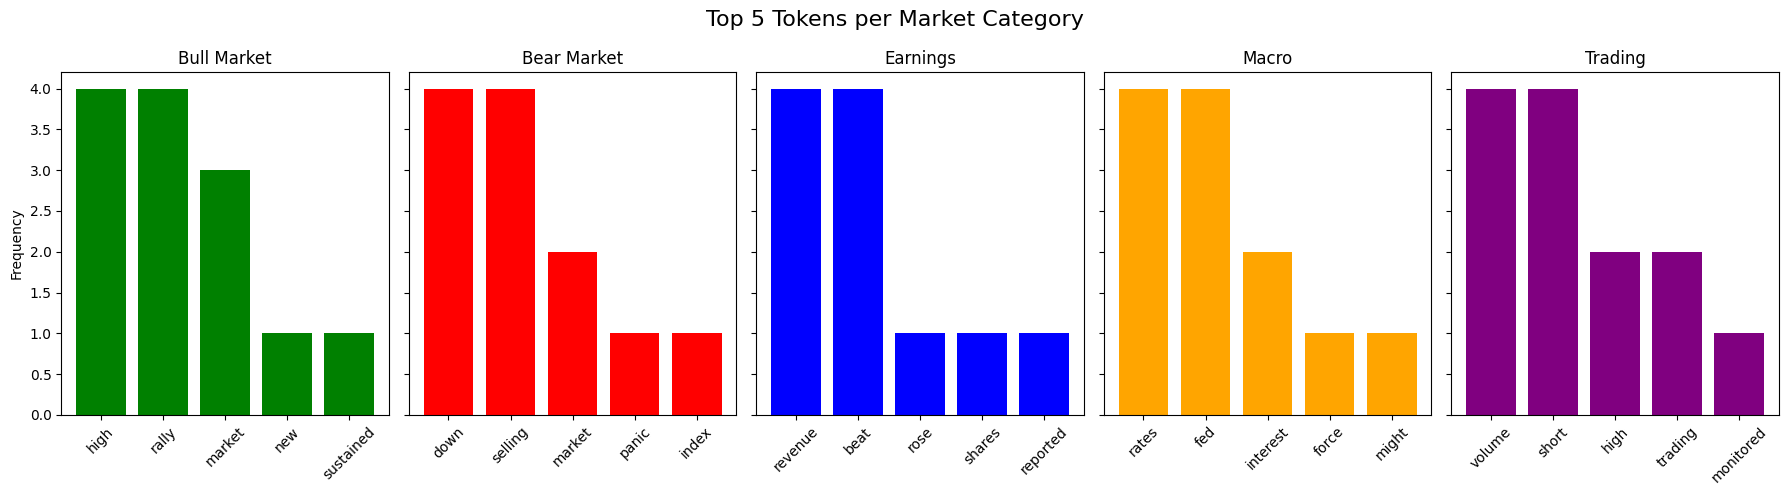

In [54]:
# Section 9 Python cell

# Define a new DataFrame that filters the category frequency DataFrame
bull_df = category_freq_df.filter(pl.col("category") == "bull_market").head(5)
bear_df = category_freq_df.filter(pl.col("category") == "bear_market").head(5)
earn_df = category_freq_df.filter(pl.col("category") == "earnings").head(5)
macro_df = category_freq_df.filter(pl.col("category") == "macro").head(5)
trade_df = category_freq_df.filter(pl.col("category") == "trading").head(5)

# --- THE GRID LAYOUT (Small Multiples) ---
# We create a 1x5 grid (1 row, 5 columns) to give each category its own space.
# figsize=(18, 5) ensures the charts aren't squashed together.
fig, axes = plt.subplots(1, 5, figsize=(18, 5), sharey=True)

# List of our filtered DataFrames and their corresponding titles for the loop
dfs = [bull_df, bear_df, earn_df, macro_df, trade_df]
titles = ["Bull Market", "Bear Market", "Earnings", "Macro", "Trading"]
colors = ["green", "red", "blue", "orange", "purple"]

# --- THE PLOTTING LOOP ---
# Loop through our "axes" (the sub-charts).
for i, ax in enumerate(axes):
    # 1. Draw the bar chart for the specific category
    ax.bar(dfs[i]["token"], dfs[i]["len"], color=colors[i])
    
    # 2. Add the title and rotate labels so "inflation" or "dividend" don't overlap
    ax.set_title(titles[i])
    ax.tick_params(axis="x", labelrotation=45)
    
    # 3. Clean up the "Big Picture" by adding a label only to the first Y-axis
    if i == 0:
        ax.set_ylabel("Frequency")

# Show results
plt.suptitle("Top 5 Tokens per Market Category", fontsize=16)
plt.tight_layout() # Adjusts spacing automatically
plt.show()

## Section 10. Interpret Results and Identify Patterns

This is a Markdown cell.

In [55]:
# Section 10 Python cell

print("\nMo GENERAL OBSERVATIONS:")
print("- Tokens cluster by category (bull_market, bear_market, earnings, macro, trading).")
print("- Words that appear in similar contexts behave similarly.")
print("- Co-occurrence reveals contextual relationships between words.")
print("- Bigrams capture local structure beyond single tokens.")
print("- Patterns emerge before any machine learning is applied.")

print("\nMo SPECIFIC OBSERVATIONS:")
print("- Frequency spikes (e.g., 'rally' vs 'selling') create a distinct 'statistical fingerprint' for each market mood.")
print("- Stopword filtering is the 'signal-to-noise' hero, removing grammatical glue to reveal the core financial 'bricks'.")
print("- The 'Market' token acts as a cross-category bridge, appearing in both Bull and Bear contexts.")
print("- Vertical bar height now reflects 'Market Heat,' showing which themes are currently driving the narrative.")
print("- Small multiples allow for instant 'Big Picture' comparison of sector volatility and focus.")


Mo GENERAL OBSERVATIONS:
- Tokens cluster by category (bull_market, bear_market, earnings, macro, trading).
- Words that appear in similar contexts behave similarly.
- Co-occurrence reveals contextual relationships between words.
- Bigrams capture local structure beyond single tokens.
- Patterns emerge before any machine learning is applied.

Mo SPECIFIC OBSERVATIONS:
- Frequency spikes (e.g., 'rally' vs 'selling') create a distinct 'statistical fingerprint' for each market mood.
- Stopword filtering is the 'signal-to-noise' hero, removing grammatical glue to reveal the core financial 'bricks'.
- The 'Market' token acts as a cross-category bridge, appearing in both Bull and Bear contexts.
- Vertical bar height now reflects 'Market Heat,' showing which themes are currently driving the narrative.
- Small multiples allow for instant 'Big Picture' comparison of sector volatility and focus.


In [56]:
# Final Python cell

LOG.info("========================")
LOG.info("Notebook executed successfully!")
LOG.info("========================")

print("Notebook executed successfully.")

2026-03-28 17:25:26 | INFO | CI | ========================
2026-03-28 17:25:26 | INFO | CI | Notebook executed successfully!
2026-03-28 17:25:26 | INFO | CI | ========================


Notebook executed successfully.
